In [1]:
import pandas as pd

In [9]:
expenses_df = pd.read_csv("Expenses_clean (1).csv")
income_df = pd.read_csv("income_clean.csv")

,date_time,category,account,amount,currency,tags
0,2025-11-30 00:00:00,Health,acct_1,114.0,BYN,tag_1
1,2025-11-29 00:00:00,Food,acct_1,5.0,BYN,tag_1
2,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1
3,2025-11-27 00:00:00,Cafe,acct_1,10.0,BYN,tag_1
4,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1


In [10]:
income_df.head()
expenses_df.head()

,date_time,category,account,amount,currency,tags
0,2025-11-30 00:00:00,Health,acct_1,114.0,BYN,tag_1
1,2025-11-29 00:00:00,Food,acct_1,5.0,BYN,tag_1
2,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1
3,2025-11-27 00:00:00,Cafe,acct_1,10.0,BYN,tag_1
4,2025-11-27 00:00:00,Public transport,acct_2,1.0,BYN,tag_1


In [12]:
income_df.info()
expenses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_time  349 non-null    object 
 1   category   349 non-null    object 
 2   account    349 non-null    object 
 3   amount     349 non-null    float64
 4   currency   349 non-null    object 
 5   tags       349 non-null    object 
dtypes: float64(1), object(5)
memory usage: 16.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_time  938 non-null    object 
 1   category   938 non-null    object 
 2   account    938 non-null    object 
 3   amount     938 non-null    float64
 4   currency   938 non-null    object 
 5   tags       938 non-null    object 
dtypes: float64(1), object(5)
memory usage: 44.1+ KB


In [14]:
income_df['Type'] = 'Income'
expenses_df['Type'] = 'Expense'

In [16]:
merged_df = pd.concat([income_df, expenses_df])

In [18]:
print(income_df.columns)
print(expenses_df.columns)

Index(['date_time', 'category', 'account', 'amount', 'currency', 'tags',
       'Type'],
      dtype='object')
Index(['date_time', 'category', 'account', 'amount', 'currency', 'tags',
       'Type'],
      dtype='object')


In [19]:
total_income = income_df['amount'].sum()
total_expense = expenses_df['amount'].sum()

profit = total_income - total_expense

print("Income:", total_income)
print("Expense:", total_expense)
print("Profit:", profit)

Income: 26629.0
Expense: 14860.0
Profit: 11769.0


In [20]:
merged_df.columns = merged_df.columns.str.strip().str.lower()

In [22]:
merged_df['date_time'] = pd.to_datetime(merged_df['date_time'])

In [23]:
merged_df['month'] = merged_df['date_time'].dt.to_period('M')

In [24]:
merged_df.rename(columns={'date_time': 'date'}, inplace=True)

In [25]:
merged_df['date'] = pd.to_datetime(merged_df['date'])
merged_df['month'] = merged_df['date'].dt.to_period('M')

In [26]:
monthly_report = merged_df.groupby(['month', 'type'])['amount'].sum().reset_index()

In [27]:
monthly_pivot = monthly_report.pivot(index='month', columns='type', values='amount')

In [28]:
monthly_pivot['profit'] = monthly_pivot['Income'] - monthly_pivot['Expense']

In [29]:
print(monthly_pivot.columns)

Index(['Expense', 'Income', 'profit'], dtype='object', name='type')


In [33]:
monthly_pivot['profit'] = monthly_pivot['Income'] - monthly_pivot['Expense']

In [34]:
monthly_pivot.to_excel("financial_report.xlsx")

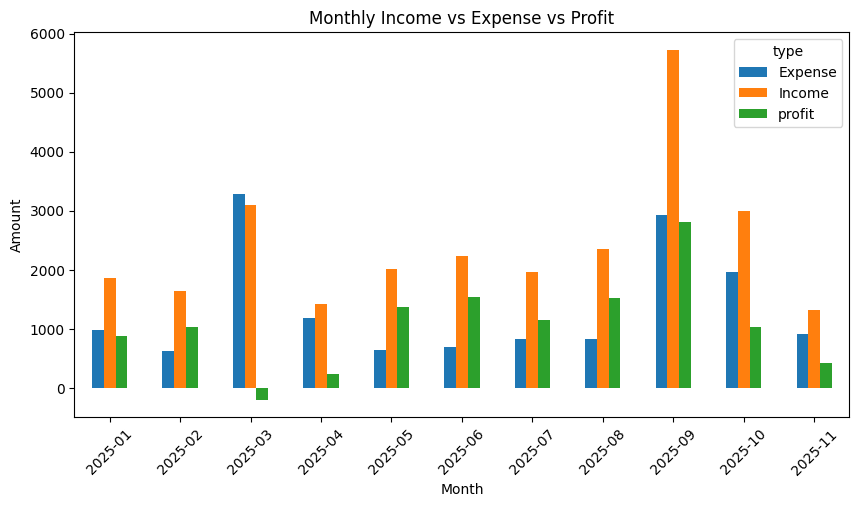

In [35]:
import matplotlib.pyplot as plt

monthly_pivot.plot(kind='bar', figsize=(10,5))
plt.title("Monthly Income vs Expense vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

In [40]:
expense_summary = expenses_df.groupby('category')['amount'].sum()


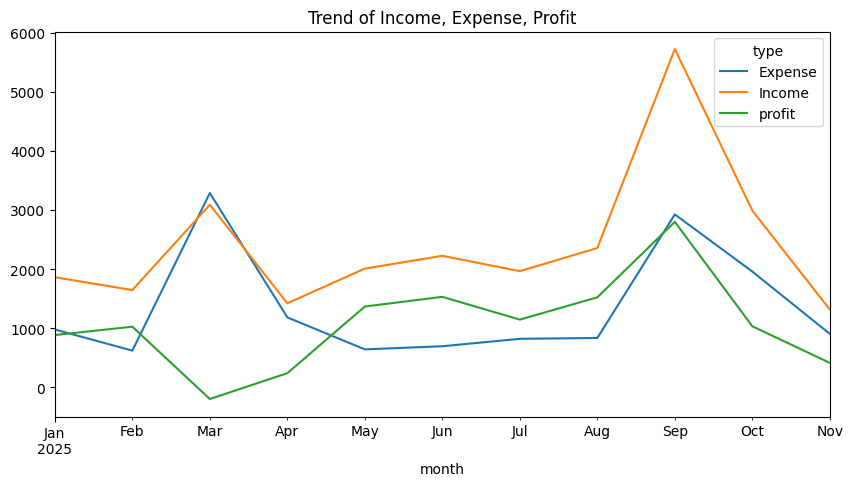

In [36]:
monthly_pivot.plot(kind='line', figsize=(10,5))
plt.title("Trend of Income, Expense, Profit")
plt.show()

In [46]:
expenses_df['category'] = expenses_df['category'].replace('Other', 'Misc')

In [48]:
expense_summary = expenses_df.groupby('category')['amount'].sum()

In [49]:
top_categories = expense_summary.nlargest(5)
others = expense_summary.sum() - top_categories.sum()

top_categories['Others'] = others

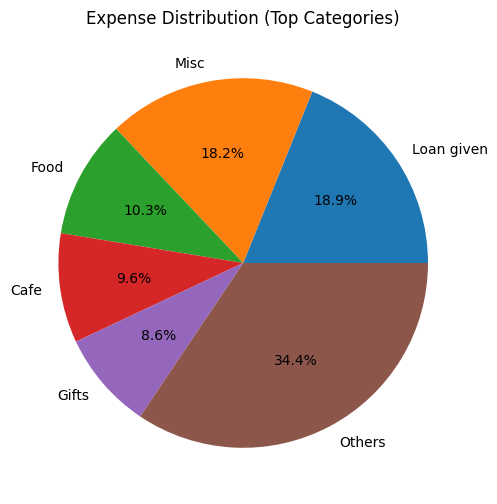

In [50]:
top_categories.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Expense Distribution (Top Categories)")
plt.ylabel('')
plt.show()